### MCA Priority Tagging

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df_prio = pd.read_excel('MCA Job list September 2025 +Priority.xlsx')
df_prio

,Job Title,Job Sector,Job Subsector,Educational Pathway,HEI with PRC (Professional Regulation Commission) Exam,Some HEI,Priority Sector (Y/N)
0,2D Echocardiography Technician,Human Health and Social Work Activities,Medical and dental practice activities,Higher Education,No,Yes,NaN
1,2D Game Artist,"Arts, entertainment and recreation","Creative, arts and entertainment activities",Not Higher Education,No,No,NaN
2,3D Game Artist,"Arts, entertainment and recreation","Creative, arts and entertainment activities",Not Higher Education,No,No,NaN
3,3D Modeller,"Arts, entertainment and recreation","Creative, arts and entertainment activities",Not Higher Education,No,No,NaN
4,3D Printing Designer,Manufacturing ...,Manufacture of other fabricated metal products...,Higher Education,No,No,NaN
...,...,...,...,...,...,...,...
1146,Window Cleaner,Accommodation and Food Service Activities,Other accommodation,Higher Education,No,No,NaN
1147,Wood Carver,Manufacturing ...,Manufacture of furniture,Not Higher Education,No,No,NaN
1148,Workforce Management Analyst,Administrative and Support Service Activities,"Business support service activities, n.e.c.",Higher Education,No,No,NaN
1149,Workforce Wellness Coordinator,Human Health and Social Work Activities,Other social work activities without accommoda...,Higher Education,No,Yes,NaN


## Pipeline:

Default: All jobs tagged N

### Advanced Manufacturing
- For all jobs under Job Sector 'Manufacturing':
- If job subsector has 'Communication', 'Electric', 'Electronic', 'Batter', 'Comput', 'Test', or 'Wiring':
  - Tag Y
- elif job title has 'Automation', 'Assemb', 'Robot', or 'Design Engineer':
  - Tag Y

### Digital Technology
- All instances in Job Title of 'Data', 'Cyber', '2D', '3D', 'Medical Claims', 'Medical Coding', 'Software', 'Digital', 'Computer', 'Mechatron', or 'Media' are tagged Y
- All instances of 'AI' (case-sensitive), 'IT' (case-sensitive), and 'IoT' (case-sensitive) are tagged Y
- All Job Titles with Job Subsector 'computer' are tagged Y

### Health
- For all jobs under Job Sector 'Human Health and Social Work Activities':
- if Job Title has 'Marriage', 'Seminary', 'Cultur', 'Missionary', 'Church', 'Chaplain', 'Clergy', 'Faith', 'Religion', or 'Religious':
  - Tag N
  - Else tag Y

### Financial Services
- All jobs under Job Sector 'Administrative and Support Service Activities', 'Financial and Insurance Activities':
  - Tag Y
- All instances in Job Title of 'E-comm' are tagged Y

### Tourism
- if Job Subsector is 'Construction', 'Water Supply; Sewerage, Waste Management and Remediation', 'Transportation and Storage', or 'Accommodation and Food Service Activities':
  - Tag Y

In [5]:
def ci_contains(s: pd.Series, pat: str) -> pd.Series:
    # Case-insensitive regex contains
    return s.astype(str).str.contains(pat, case=False, regex=True, na=False)

jt  = df_prio['Job Title'].astype(str)
js  = df_prio['Job Sector'].astype(str)
jss = df_prio['Job Subsector'].astype(str)

# Default N
df_prio['Priority Sector (Y/N)'] = 'N'



# Advanced Manufacturing
is_mfg = ci_contains(js, r'manufacturing')
mfg_sub = ci_contains(jss, r'communication|electric|electronic|batter|comput|test|wiring')
mfg_title = ci_contains(jt, r'automation|assemb|robot|design engineer')
df_prio.loc[is_mfg & (mfg_sub | mfg_title), 'Priority Sector (Y/N)'] = 'Y'



# Digital Technology
dig_title = ci_contains(
    jt,
    r'data|cyber|2d|3d|medical\s+claims|medical\s+coding|software|digital|computer|mechatron|media'
)
df_prio.loc[dig_title, 'Priority Sector (Y/N)'] = 'Y'

ai_it_iot = (
    df_prio['Job Title'].str.contains('AI',  case=True, regex=True, na=False) |
    df_prio['Job Title'].str.contains('IT',  case=True, regex=True, na=False) |
    df_prio['Job Title'].str.contains('IoT', case=True, regex=True, na=False)
)
df_prio.loc[ai_it_iot, 'Priority Sector (Y/N)'] = 'Y'

subsector_has_computer = ci_contains(jss, r'computer')
df_prio.loc[subsector_has_computer, 'Priority Sector (Y/N)'] = 'Y'



# Health
is_health = ci_contains(js, r'human\s+health\s+and\s+social\s+work\s+activities')
health_exclude = ci_contains(
    jt,
    r'marriage|seminary|cultur|missionary|church|chaplain|clergy|faith|religion|religious'
)

df_prio.loc[is_health, 'Priority Sector (Y/N)'] = 'Y'
df_prio.loc[is_health & health_exclude, 'Priority Sector (Y/N)'] = 'N'



# Financial Services
is_admin_support = ci_contains(js, r'administrative\s+and\s+support\s+service\s+activities')
is_fin_ins       = ci_contains(js, r'financial\s+and\s+insurance\s+activities')
df_prio.loc[is_admin_support | is_fin_ins, 'Priority Sector (Y/N)'] = 'Y'

df_prio.loc[ci_contains(jt, r'e-comm'), 'Priority Sector (Y/N)'] = 'Y'



# Tourism
tourism_sector = ci_contains(
    js,
    r'\bconstruction\b'
    r'|water\s*supply;?\s*sewerage,?\s*waste(\s*management)?\s*(and\s*remediation)?(\s*activities)?'
    r'|transportation\s*(and)?\s*storage'
    r'|accommodation\s*(and)?\s*food(\s*service)?\s*(activities)?'
    r'|hospitality'
    r'|tourism'
)

df_prio.loc[tourism_sector, 'Priority Sector (Y/N)'] = 'Y'

/tmp/ipykernel_653/3703163749.py:3: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  return s.astype(str).str.contains(pat, case=False, regex=True, na=False)


In [6]:
df_prio

,Job Title,Job Sector,Job Subsector,Educational Pathway,HEI with PRC (Professional Regulation Commission) Exam,Some HEI,Priority Sector (Y/N)
0,2D Echocardiography Technician,Human Health and Social Work Activities,Medical and dental practice activities,Higher Education,No,Yes,Y
1,2D Game Artist,"Arts, entertainment and recreation","Creative, arts and entertainment activities",Not Higher Education,No,No,Y
2,3D Game Artist,"Arts, entertainment and recreation","Creative, arts and entertainment activities",Not Higher Education,No,No,Y
3,3D Modeller,"Arts, entertainment and recreation","Creative, arts and entertainment activities",Not Higher Education,No,No,Y
4,3D Printing Designer,Manufacturing ...,Manufacture of other fabricated metal products...,Higher Education,No,No,Y
...,...,...,...,...,...,...,...
1146,Window Cleaner,Accommodation and Food Service Activities,Other accommodation,Higher Education,No,No,Y
1147,Wood Carver,Manufacturing ...,Manufacture of furniture,Not Higher Education,No,No,N
1148,Workforce Management Analyst,Administrative and Support Service Activities,"Business support service activities, n.e.c.",Higher Education,No,No,Y
1149,Workforce Wellness Coordinator,Human Health and Social Work Activities,Other social work activities without accommoda...,Higher Education,No,Yes,Y


In [8]:
df_prio.to_excel('MCA Job List Tagged Final.xlsx', index=False)

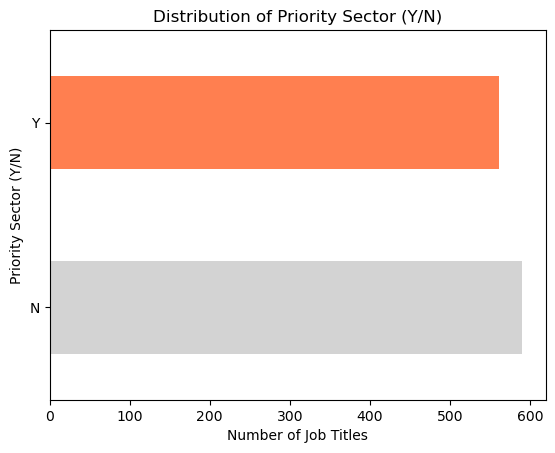

In [26]:
# Distribution of Priority Sector counts

counts = df_prio['Priority Sector (Y/N)'].value_counts()
counts.plot(kind='barh', color=['#D3D3D3', '#FF7F50'], width=0.5)

plt.xlabel('Number of Job Titles')
plt.ylabel('Priority Sector (Y/N)')
plt.title('Distribution of Priority Sector (Y/N)')
plt.show()